# Compare reranker models for viral-worthiness

The reranker is the **accuracy stage** of the cascade: it regresses a continuous
`viral_score` (0–1 in-category engagement percentile) so the candidate lines the
detector kept can be **ordered**. This notebook fine-tunes several strong
multilingual encoders on that regression task and compares their **ranking**
quality on the held-out test set.

Metrics (all on test):
- **Spearman** — rank correlation of predicted vs. true `viral_score` (the
  canonical ordering metric).
- **nDCG@10** — quality of the top of the ranking.
- **MSE** — regression error (lower is better).

Models (multilingual + cased, since ~58% of titles are non-ASCII):

| Model | Notes |
|-------|-------|
| `microsoft/mdeberta-v3-base` | multilingual DeBERTa-v3 — best accuracy/param |
| `xlm-roberta-base` | strong multilingual baseline |
| `bert-base-multilingual-cased` | mBERT, lighter |

Unlike the detector, the ranker trains on **all** rows (full 0–1 range), not just
the top/bottom-quartile subset.

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers", "torch", "datasets", "accelerate",
                "scikit-learn", "scipy", "pandas", "matplotlib",
                "sentencepiece", "protobuf"], check=True)


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['/Users/angie/miniforge3/envs/Thermal/bin/python', '-m', 'pip', 'install', '-q', 'transformers', 'torch', 'datasets', 'accelerate', 'scikit-learn', 'scipy', 'pandas', 'matplotlib', 'sentencepiece', 'protobuf'], returncode=0)

## Config

In [1]:
import os

# Lift PyTorch's MPS memory ceiling; must run before torch is imported.
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")

def _find(name):
    for p in [name, os.path.join("youtube_title_trending", name)]:
        if os.path.exists(p):
            return p
    return name
PROC_DIR = os.path.dirname(_find(os.path.join("processed", "train.parquet")))

# Multilingual rerankers to compare.
MODELS = [
    "xlm-roberta-base",               # strong multilingual baseline
    "bert-base-multilingual-cased",   # mBERT (lighter)
]

MAX_LEN    = 64
EPOCHS     = 3
BATCH_SIZE = 8       # MPS-friendly; drop to 4 if you hit OOM (and restart kernel!)
GRAD_ACCUM = 2       # effective batch = 16
LR         = 2e-5
NDCG_K     = 10
LIMIT_TRAIN = None   # set an int for a quick smaller run
print("data dir:", PROC_DIR)

data dir: processed


In [2]:
import gc, time
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", DEVICE)

def load_split(name):
    df = pd.read_parquet(os.path.join(PROC_DIR, f"{name}.parquet")).copy()
    df["viral_score"] = df["viral_score"].astype("float32")
    return df

train_df, val_df, test_df = load_split("train"), load_split("val"), load_split("test")
if LIMIT_TRAIN:
    train_df = train_df.head(LIMIT_TRAIN)
print(f"rows -> train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

/Users/angie/miniforge3/envs/Thermal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
rows -> train 7323 | val 915 | test 916


## Train + evaluate one reranker

In [3]:
def make_ds(df, tok):
    d = Dataset.from_pandas(df[["video_title", "viral_score"]]
                            .rename(columns={"video_title": "text", "viral_score": "labels"}),
                            preserve_index=False)
    return d.map(lambda b: tok(b["text"], truncation=True, max_length=MAX_LEN),
                 batched=True, remove_columns=["text"])

def reg_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.squeeze()
    return {"spearman": spearmanr(preds, labels).correlation,
            "mse": float(np.mean((preds - labels) ** 2))}

def train_and_eval(model_name):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)
    model.config.problem_type = "regression"
    args = TrainingArguments(
        output_dir=f"models/rerank/{model_name.replace('/', '_')}",
        num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="no", logging_steps=100, report_to="none")
    trainer = Trainer(model=model, args=args,
                      train_dataset=make_ds(train_df, tok), eval_dataset=make_ds(val_df, tok),
                      data_collator=DataCollatorWithPadding(tok), processing_class=tok,
                      compute_metrics=reg_metrics)
    t0 = time.time()
    trainer.train()
    train_sec = time.time() - t0

    # Ranking metrics on the held-out test set.
    pred = trainer.predict(make_ds(test_df, tok)).predictions.squeeze()
    true = test_df["viral_score"].to_numpy()
    result = {"model": model_name,
              "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6),
              "spearman": round(spearmanr(pred, true).correlation, 4),
              f"ndcg@{NDCG_K}": round(ndcg_score([true], [pred], k=NDCG_K), 4),
              "mse": round(float(np.mean((pred - true) ** 2)), 4),
              "train_sec": round(train_sec)}
    del model, trainer
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    return result

## Run the comparison

Trains every model in `MODELS` (slow; first run downloads each checkpoint).
**Restart the kernel first** if you've been running other models — MPS memory
from earlier runs can cause OOM.

In [4]:
results = []
for name in MODELS:
    print(f"=== {name} ===")
    results.append(train_and_eval(name))
    print("  ", results[-1])

=== xlm-roberta-base ===


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10672.94it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 91

Epoch,Training Loss,Validation Loss,Spearman,Mse
1,0.164611,0.081402,0.441188,0.081402
2,0.121288,0.069236,0.494057,0.069236
3,0.112324,0.066763,0.510080,0.066763


Map: 100%|██████████| 916/916 [00:00<00:00, 31395.67 examples/s]
/Users/angie/miniforge3/envs/Thermal/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


   {'model': 'xlm-roberta-base', 'params_M': 278, 'spearman': np.float64(0.5864), 'ndcg@10': 0.7146, 'mse': 0.0547, 'train_sec': 1073}
=== bert-base-multilingual-cased ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10028.67it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from 

Epoch,Training Loss,Validation Loss,Spearman,Mse
1,0.136540,0.069117,0.473868,0.069117
2,0.101259,0.062673,0.532212,0.062673
3,0.074306,0.064038,0.530761,0.064038


Map: 100%|██████████| 916/916 [00:00<00:00, 68956.54 examples/s]
/Users/angie/miniforge3/envs/Thermal/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


   {'model': 'bert-base-multilingual-cased', 'params_M': 178, 'spearman': np.float64(0.5699), 'ndcg@10': 0.8494, 'mse': 0.0572, 'train_sec': 755}


## Results

In [5]:
table = pd.DataFrame(results).sort_values("spearman", ascending=False).reset_index(drop=True)
table

,model,params_M,spearman,ndcg@10,mse,train_sec
0,xlm-roberta-base,278,0.5864,0.7146,0.0547,1073
1,bert-base-multilingual-cased,178,0.5699,0.8494,0.0572,755


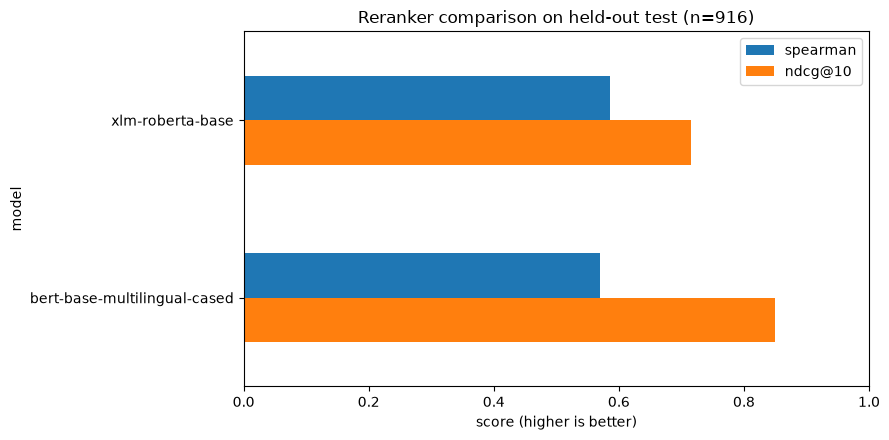

In [6]:
import matplotlib.pyplot as plt

ax = table.set_index("model")[["spearman", f"ndcg@{NDCG_K}"]].plot(kind="barh", figsize=(9, 4.5))
ax.set_title(f"Reranker comparison on held-out test (n={len(test_df)})")
ax.set_xlabel("score (higher is better)"); ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout(); plt.show()